# PHY588 - Problem 1 - Frequentist Regression
Frequentist Regression of Astronomical Light Curve

This notebook performs Maximum Likelihood Estimation (MLE) to fit a sinusoidal model to astronomical light curve data.

Scientific Goal
Model periodic variability in flux using a sinusoidal model.


Theory

Model Definition
We model the light curve as:

$f(t) = A \sin\left(\frac{2\pi t}{P} + \phi\right) + C$ Where:
- $A$ = amplitude  
- $P$ = period  
- $\phi$ = phase  
- $C$ = baseline flux

Likelihood Function

Assuming Gaussian errors:

$P(y_i | \theta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - f(t_i;\theta))^2}{2\sigma^2}\right)$\n\nFor N independent data points:

$\log L = -\frac{1}{2} \sum_i \frac{(y_i - f(t_i))^2}{\sigma^2} + constant$\n\nMaximizing log-likelihood is equivalent to minimizing:

$\chi^2 = \sum_i (y_i - f(t_i))^2$\n


1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

2. Load Data

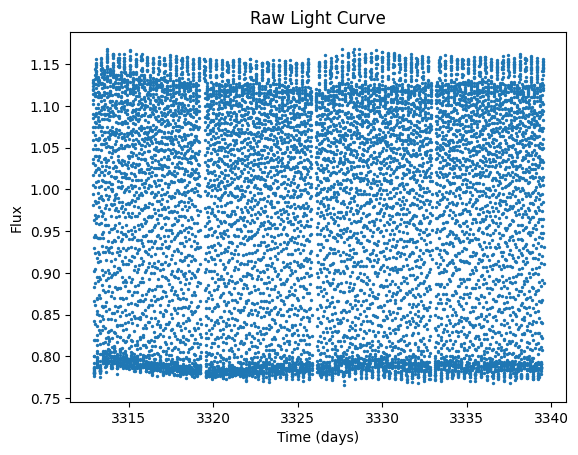

In [2]:
data = np.loadtxt('lightcurve_sector74.txt')
t = data[:,0]
y = data[:,1]

len(y)

plt.figure()
plt.scatter(t, y, s=2)
plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Raw Light Curve")
plt.show()

3. Define Sinusoidal Model

In [3]:
def sinusoid_model(theta, t):
    A, P, phi, C = theta
    return A * np.sin(2*np.pi*t/P + phi) + C

4. Define Chi-Square Function

In [4]:
def chi_square(theta):
    model_flux = sinusoid_model(theta, t)
    return np.sum((y - model_flux)**2)

5. Initial Guess and Optimization

In [12]:
A_guess = 0.4
C_guess = np.mean(y)
P_guess = 0.3393
phi_guess = 0.0

initial_guess = [A_guess, P_guess, phi_guess, C_guess]

result = minimize(chi_square, initial_guess)

best_fit_params = result.x
print(best_fit_params)

[ 0.01366924  0.33947589 -0.15730464  0.97210915]


6. Goodness of Fit

In [13]:
N = len(y)
k = 4
chi2_min = chi_square(best_fit_params)
reduced_chi2 = chi2_min / (N - k)

chi2_min, reduced_chi2

(np.float64(199.98994082789858), np.float64(0.01775478878088588))

7. Plot Data and Best-Fit Model

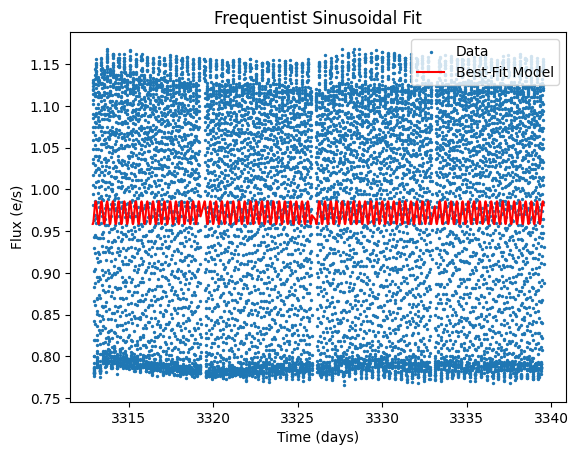

In [14]:
plt.figure()
plt.scatter(t, y, s=2, label="Data")
plt.plot(t, sinusoid_model(best_fit_params, t),
         color='red',
         label="Best-Fit Model")

plt.xlabel('Time (days)')
plt.ylabel('Flux (e/s)')
plt.title('Frequentist Sinusoidal Fit')

plt.legend()
plt.show()

8. Model Selection using AIC

In [15]:
AIC = chi2_min + 2*k
AIC

np.float64(207.98994082789858)